 # Exploratory Data Analysis for KIS power grid outages

## Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from datetime import timedelta

## Data collection

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/POWER_GRID_AI_PREDICITIVE_MAINTENANCE/refs/heads/feature1/poweroutage2024final.csv')

In [5]:
# Setting plot style
sns.set(style="whitegrid")

## Checking data properties

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STARTDATEANDTIME  250 non-null    object
 1   ENDDATEANDTIME    250 non-null    object
 2   DURATION          250 non-null    object
dtypes: object(3)
memory usage: 6.0+ KB


In [7]:
df.head()

,STARTDATEANDTIME,ENDDATEANDTIME,DURATION
0,02/01/2024 15:51,02/01/2024 15:52,00:24
1,06/01/2024 14:58,06/01/2024 15:01,00:03
2,08/01/2024 14:29,08/01/2024 14:30,00:01
3,12/01/2024 08:45,12/01/2024 08:46,00:01
4,16/01/2024 12:58,16/01/2024 13:00,00:02


## Data preprocessing

In [8]:
# ensuring date is in date time
df['STARTDATEANDTIME'] = pd.to_datetime(df['STARTDATEANDTIME'], format='%d/%m/%Y %H:%M')
df['ENDDATEANDTIME'] = pd.to_datetime(df['ENDDATEANDTIME'], format='%d/%m/%Y %H:%M')

In [9]:
# Converting Duration to minutes
def duration_to_minutes(duration):
    h, m = map(int, duration.split(':'))
    return h * 60 + m

df['DURATION_MINUTES'] = df['DURATION'].apply(duration_to_minutes)

In [10]:
# Extracting temporal features
df['Month'] = df['STARTDATEANDTIME'].dt.month_name()
df['Hour'] = df['STARTDATEANDTIME'].dt.hour
df['Day_of_week'] = df['STARTDATEANDTIME'].dt.day_name()
df['Date'] = df['STARTDATEANDTIME'].dt.date
df['Quarter'] = df['STARTDATEANDTIME'].dt.quarter
df = df.sort_values('STARTDATEANDTIME')

In [11]:
# Outliers
Q1 = df['DURATION_MINUTES'].quantile(0.25)
Q3 = df['DURATION_MINUTES'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df['DURATION_MINUTES'] > (Q3 + 1.5 * IQR)]
print("\nOutliers (Duration > Q3 + 1.5*IQR):")
print(outliers[['STARTDATEANDTIME', 'DURATION_MINUTES']].head())


Outliers (Duration > Q3 + 1.5*IQR):
      STARTDATEANDTIME  DURATION_MINUTES
31 2024-02-27 04:50:00               365
30 2024-02-27 04:50:00               253
37 2024-03-08 11:30:00               367
44 2024-03-14 10:00:00               250
43 2024-03-14 10:11:00               260


## Business questions

In [13]:
#question1: When are outages most likely to occur,and how can KIS prepare?
print("\n1. When are outages most likely to occur, and how can we prepare?")
monthlycounts = df['Month'].value_counts()
peakmonth = monthlycounts.idxmax()
peakmonthcount = monthlycounts.max()
quartercounts = df['Quarter'].value_counts()
peakquarter = quartercounts.idxmax()
hourlycounts = df['Hour'].value_counts()
peakhours = hourlycounts.index[:2].tolist()  # Top 2 hours
print(f"   - Peak Month: {peakmonth} ({peakmonthcount} outages)")
print(f"   - Peak Quarter: Q{peakquarter} ({quartercounts.max()} outages)")
print(f"   - Peak Hours: {peakhours[0]}:00 and {peakhours[1]}:00")
print("   - Preparation: Increase staffing and preventive maintenance in late fall (i.e., November), especially 8–10 AM and 5–8 PM.")


1. When are outages most likely to occur, and how can we prepare?
   - Peak Month: November (49 outages)
   - Peak Quarter: Q4 (109 outages)
   - Peak Hours: 10:00 and 8:00
   - Preparation: Increase staffing and preventive maintenance in late fall (i.e., November), especially 8–10 AM and 5–8 PM.


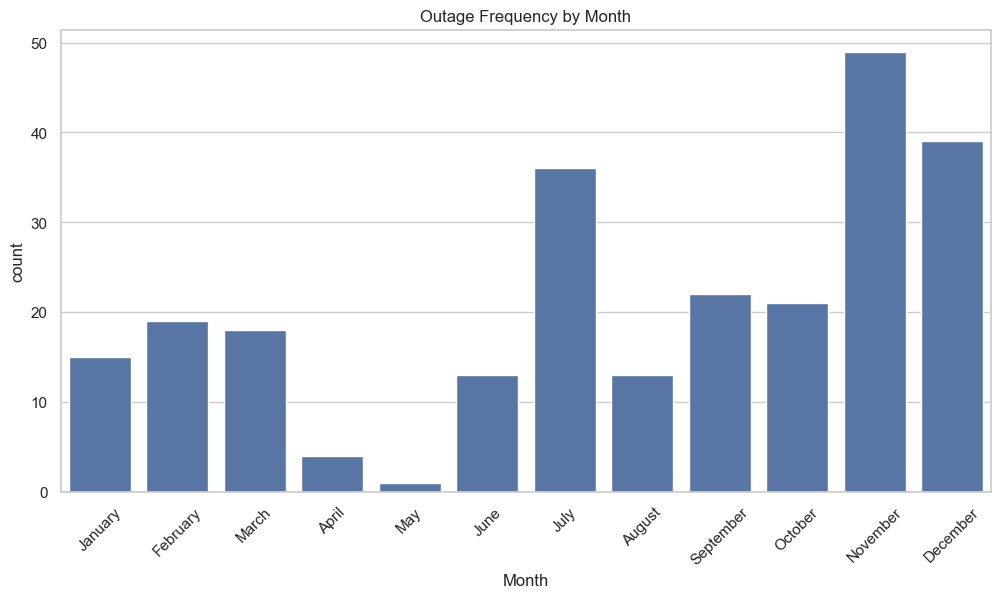

In [14]:
plt.figure(figsize=(12, 6))
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
         'September', 'October', 'November', 'December']
sns.countplot(data=df, x='Month', order=order)
plt.title('Outage Frequency by Month')
plt.xticks(rotation=45)
plt.show()

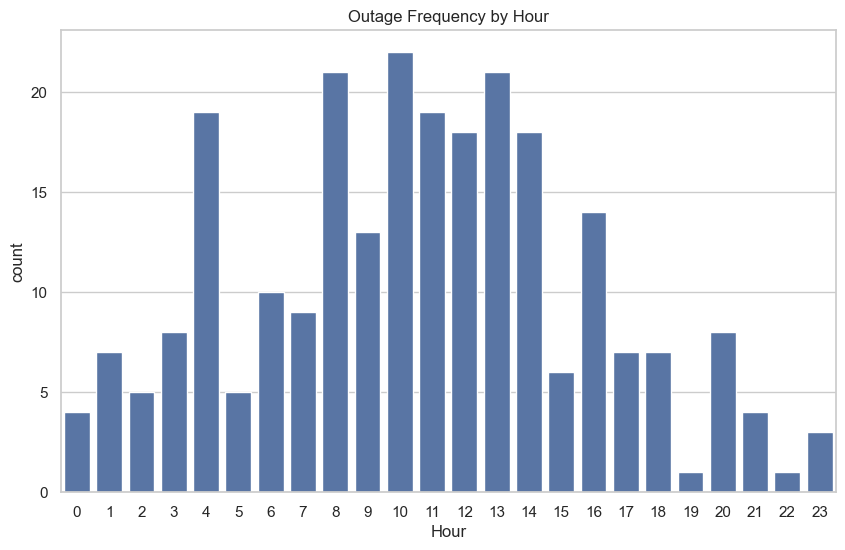

In [15]:
# Further visualization of Q1
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Hour')
plt.title('Outage Frequency by Hour')
plt.show()

In [16]:
# Question 2: What is the typical duration of an outage, and how does it impact KIS operations?
print("\n2. What is the typical duration of an outage, and how does it impact KIS operations?")
medianduration = df['DURATION_MINUTES'].median()
shortoutages = len(df[df['DURATION_MINUTES'] < 10]) / len(df) * 100
longoutages = len(df[df['DURATION_MINUTES'] > 60]) / len(df) * 100
maxduration = df['DURATION_MINUTES'].max()
maxdurationdate = df.loc[df['DURATION_MINUTES'].idxmax(), 'STARTDATEANDTIME']
print(f"   - Median Duration: {medianduration} minutes")
print(f"   - Short Outages (<10 min): {shortoutages:.1f}%")
print(f"   - Long Outages (>1 hr): {longoutages:.1f}%")
print(f"   - Max Duration: {maxduration} minutes (on {maxdurationdate})")
print("   - Impact: Plan for quick recovery for most outages; prepare contingencies for rare, long events.")


2. What is the typical duration of an outage, and how does it impact KIS operations?
   - Median Duration: 17.5 minutes
   - Short Outages (<10 min): 39.6%
   - Long Outages (>1 hr): 30.8%
   - Max Duration: 710 minutes (on 2024-06-01 00:00:00)
   - Impact: Plan for quick recovery for most outages; prepare contingencies for rare, long events.


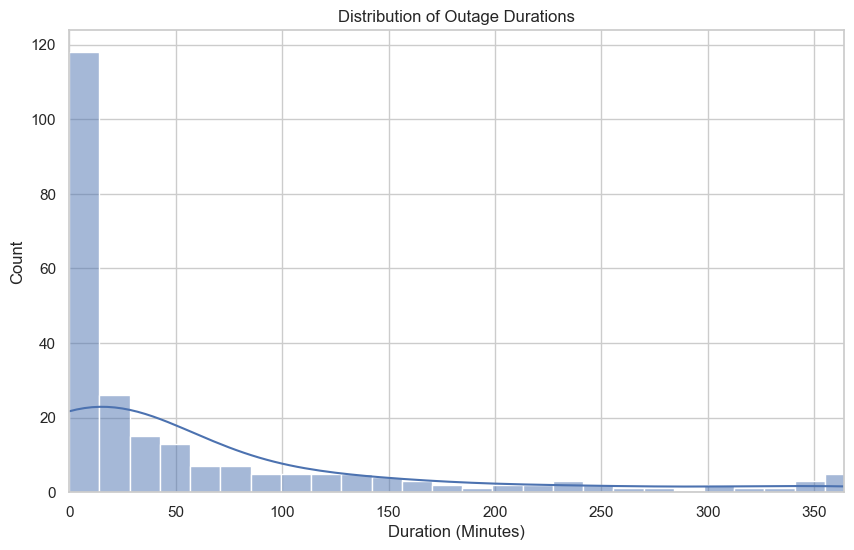

In [17]:
# Visualization for Q2
plt.figure(figsize=(10, 6))
sns.histplot(df['DURATION_MINUTES'], bins=50, kde=True)
plt.title('Distribution of Outage Durations')
plt.xlabel('Duration (Minutes)')
plt.xlim(0, df['DURATION_MINUTES'].quantile(0.95))
plt.show()

In [18]:
# Question 3: Are there specific_days or times when outages are more severe?
print("\n3. Are there specific days or times when outages are more severe?")
mediandurationbyday = df.groupby('Day_of_week')['DURATION_MINUTES'].median()
maxday = mediandurationbyday.idxmax()
mediandurationbyhour = df.groupby('Hour')['DURATION_MINUTES'].median()
maxhour = mediandurationbyhour.idxmax()
severeoutages = df[df['DURATION_MINUTES'] > 300]  # >5 hours
print(f"   - Day with Highest Median Duration: {maxday} ({mediandurationbyday.max()} minutes)")
print(f"   - Hour with Highest Median Duration: {maxhour}:00 ({mediandurationbyhour.max()} minutes)")
print(f"   - Severe Outages (>5 hrs): {len(severeoutages)} events, mostly in Q4 (e.g., {severeoutages['STARTDATEANDTIME'].iloc[0]})")
print("   - Action: Enhance monitoring on weekends (e.g., Sundays) and early mornings (e.g., 4 AM), especially in Q4.")


3. Are there specific days or times when outages are more severe?
   - Day with Highest Median Duration: Tuesday (23.0 minutes)
   - Hour with Highest Median Duration: 0:00 (465.0 minutes)
   - Severe Outages (>5 hrs): 23 events, mostly in Q4 (e.g., 2024-02-27 04:50:00)
   - Action: Enhance monitoring on weekends (e.g., Sundays) and early mornings (e.g., 4 AM), especially in Q4.


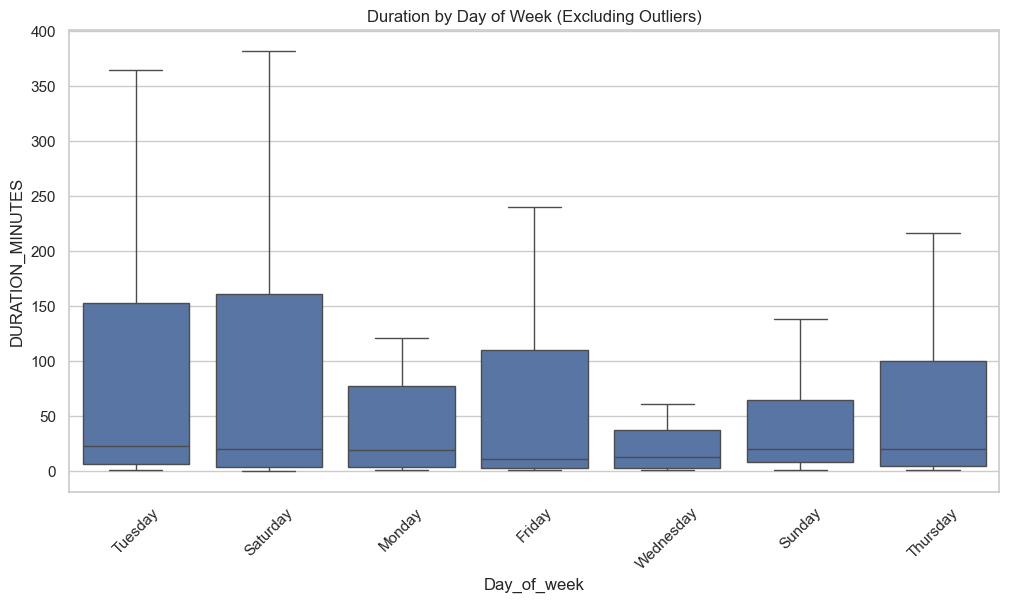

In [19]:
# Visualization for Q3
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Day_of_week', y='DURATION_MINUTES', showfliers=False)
plt.title('Duration by Day of Week (Excluding Outliers)')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Question 4: How often do outages cluster, and what does this imply for system reliability?
# Add clustering feature
df['TIME_DIFF'] = df['STARTDATEANDTIME'].diff().dt.total_seconds() / 60
df['CLUSTER_ID'] = (df['TIME_DIFF'] > 60).cumsum()
cluster_summary = df.groupby('CLUSTER_ID').agg({
    'STARTDATEANDTIME': ['min', 'count'], 'ENDDATEANDTIME': 'max',
    'DURATION_MINUTES': 'sum'
}).reset_index()
cluster_summary.columns = ['CLUSTER_ID', 'START_TIME', 'OUTAGE_COUNT', 'END_TIME', 'TOTAL_DURATION']
print("\n4. How often do outages cluster, and what does this imply for system reliability?")
num_clusters = df['CLUSTER_ID'].nunique()
multi_clusters = len(cluster_summary[cluster_summary['OUTAGE_COUNT'] > 1])
simultaneous_outages = len(df[df['TIME_DIFF'] == 0])
max_cluster = cluster_summary.loc[cluster_summary['OUTAGE_COUNT'].idxmax()]
print(f"   - Total Clusters: {num_clusters}")
print(f"   - Multi-Outage Clusters: {multi_clusters}")
print(f"   - Simultaneous Outages: {simultaneous_outages}")
print(f"   - Largest Cluster: {max_cluster['OUTAGE_COUNT']} outages on {max_cluster['START_TIME']}")
print("   - Implication: Frequent clustering suggests system instability; investigate root causes and add redundancy.")


4. How often do outages cluster, and what does this imply for system reliability?
   - Total Clusters: 200
   - Multi-Outage Clusters: 37
   - Simultaneous Outages: 31
   - Largest Cluster: 4 outages on 2024-03-14 10:00:00
   - Implication: Frequent clustering suggests system instability; investigate root causes and add redundancy.


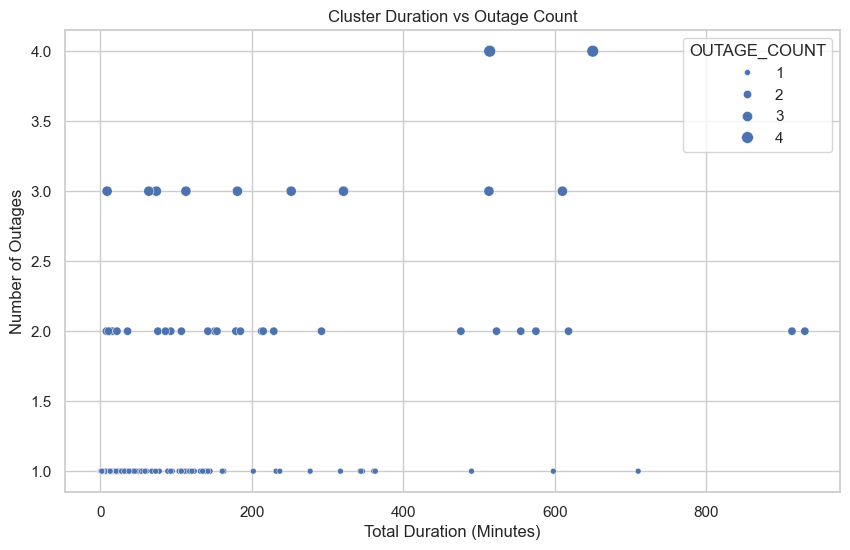

In [21]:
# Visualization for Q4
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_summary, x='TOTAL_DURATION', y='OUTAGE_COUNT', size='OUTAGE_COUNT')
plt.title('Cluster Duration vs Outage Count')
plt.xlabel('Total Duration (Minutes)')
plt.ylabel('Number of Outages')
plt.show()

In [22]:
# Question 5: What patterns can we use to predict and prevent future outages?
print("\n5. What patterns can we use to predict and prevent future outages?")
mediantime_diff = df['TIME_DIFF'].median()
peakhours_rate = df.groupby('Hour')['DURATION_MINUTES'].count().idxmax()
rollingavg_sample = df['DURATION_MINUTES'].rolling(window=5, min_periods=1).mean().iloc[-1]
print(f"   - Median Time Between Outages: {mediantime_diff:.0f} minutes (~{mediantime_diff/60:.1f} hrs)")
print(f"   - Peak Hourly Rate: {peakhours_rate}:00")
print(f"   - Sample Rolling Avg Duration (last 5): {rollingavg_sample:.1f} minutes")
print(f"   - Q4 Spike: {quartercounts[4]} outages")
print("   - Prevention: Use time since last outage, rolling averages, and hourly rates in models; prioritize pre-Q4 maintenance and peak-hour monitoring.")


5. What patterns can we use to predict and prevent future outages?
   - Median Time Between Outages: 697 minutes (~11.6 hrs)
   - Peak Hourly Rate: 10:00
   - Sample Rolling Avg Duration (last 5): 130.6 minutes
   - Q4 Spike: 109 outages
   - Prevention: Use time since last outage, rolling averages, and hourly rates in models; prioritize pre-Q4 maintenance and peak-hour monitoring.


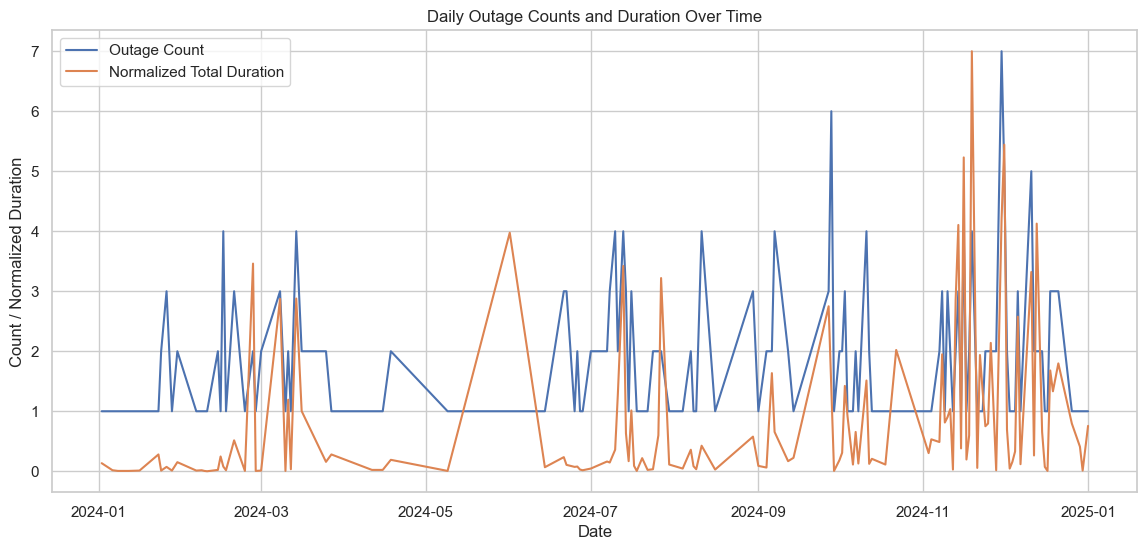

In [23]:
dailycounts = df.groupby('Date').size()
dailyduration = df.groupby('Date')['DURATION_MINUTES'].sum()
plt.figure(figsize=(14, 6))
plt.plot(dailycounts.index, dailycounts, label='Outage Count')
plt.plot(dailyduration.index, dailyduration / dailyduration.max() * dailycounts.max(),
         label='Normalized Total Duration')
plt.title('Daily Outage Counts and Duration Over Time')
plt.xlabel('Date')
plt.ylabel('Count / Normalized Duration')
plt.legend()
plt.show()


6. How does the distribution of outages across days and hours (heatmap) inform scheduling of maintenance crews to minimize downtime?
   - Peak Day-Hour: Friday at 8:00 (7 outages)
   - Top 3 High-Outage Hours: 10:00, 8:00, 13:00
   - Top 2 High-Outage Days: Friday, Saturday
   - Scheduling: Deploy crews proactively on Saturdays and Sundays, with focus on 8–10 AM and 13:00; preemptive checks before these peaks reduce downtime.


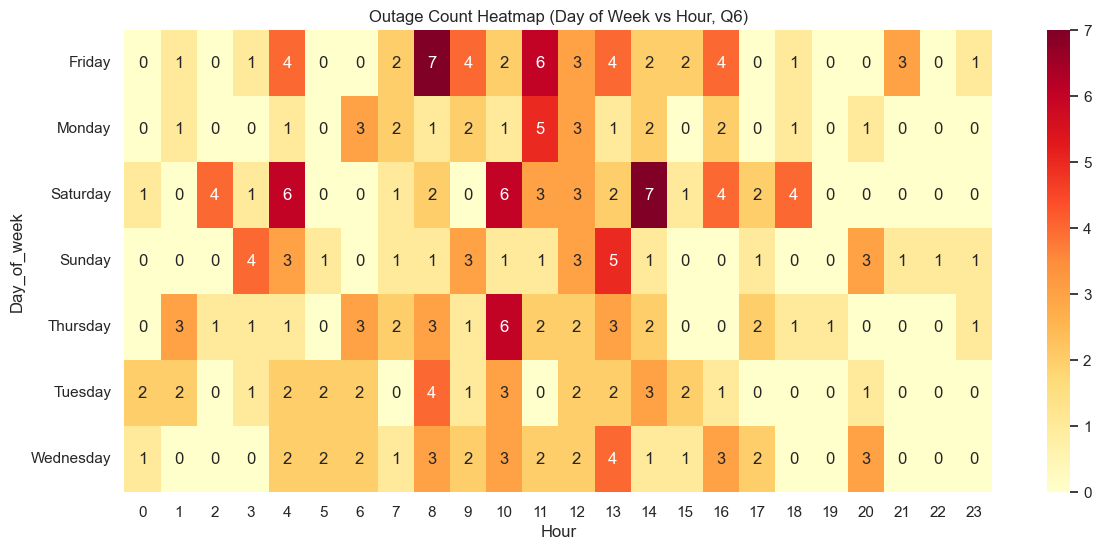

In [24]:
# Q6: How does the distribution of outages across days and hours inform scheduling of maintenance crews?
print("\n6. How does the distribution of outages across days and hours (heatmap) inform scheduling of maintenance crews to minimize downtime?")
heatmapdata = df.pivot_table(index='Day_of_week', columns='Hour', values='DURATION_MINUTES',
                              aggfunc='count', fill_value=0)
peakdayhour = heatmapdata.stack().idxmax()
peakdayhourcount = heatmapdata.stack().max()
highoutagehours = heatmapdata.sum(axis=0).nlargest(3).index.tolist()
highoutagedays = heatmapdata.sum(axis=1).nlargest(2).index.tolist()
print(f"   - Peak Day-Hour: {peakdayhour[0]} at {peakdayhour[1]}:00 ({peakdayhourcount} outages)")
print(f"   - Top 3 High-Outage Hours: {', '.join([f'{h}:00' for h in highoutagehours])}")
print(f"   - Top 2 High-Outage Days: {', '.join(highoutagedays)}")
print("   - Scheduling: Deploy crews proactively on Saturdays and Sundays, with focus on 8–10 AM and 13:00; preemptive checks before these peaks reduce downtime.")
plt.figure(figsize=(14, 6))
sns.heatmap(heatmapdata, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Outage Count Heatmap (Day of Week vs Hour, Q6)')
plt.show()

In [25]:
# 9. Summary Insights
print("\n===Insights ===")
print(f"Median duration: {df['DURATION_MINUTES'].median()} minutes")
print(f"Max duration: {df['DURATION_MINUTES'].max()} minutes (Date: {df.loc[df['DURATION_MINUTES'].idxmax(), 'STARTDATEANDTIME']})")
print(f"Number of clusters: {df['CLUSTER_ID'].nunique()}")
print(f"Multi outage clusters: {len(cluster_summary[cluster_summary['OUTAGE_COUNT'] > 1])}")


===Insights ===
Median duration: 17.5 minutes
Max duration: 710 minutes (Date: 2024-06-01 00:00:00)
Number of clusters: 200
Multi outage clusters: 37


In [26]:
# Calculate time since last outage (in minutes)
df = df.sort_values('STARTDATEANDTIME')
df['TIMESINCELASTOUTAGE'] = df['STARTDATEANDTIME'].diff().dt.total_seconds() / 60
df['TIMESINCELASTOUTAGE'] = df['TIMESINCELASTOUTAGE'].fillna(0)  # Fill first entry with 0

# 2. Spearman Correlation Test
# Perform the test between DURATION_MINUTES and TIME_SINCE_LAST_OUTAGE
correlation, p_value = spearmanr(df['DURATION_MINUTES'], df['TIMESINCELASTOUTAGE'])

# Print results
print("=== Spearman Correlation Test ===")
print(f"Variables: DURATION_MINUTES vs TIMESINCELASTOUTAGE")
print(f"Spearman Correlation Coefficient (ρ): {correlation:.3f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Reject null hypothesis (H₀). There is a statistically significant monotonic relationship.")
else:
    print("Result: Fail to reject null hypothesis (H₀). No significant monotonic relationship detected.")

=== Spearman Correlation Test ===
Variables: DURATION_MINUTES vs TIMESINCELASTOUTAGE
Spearman Correlation Coefficient (ρ): -0.269
P-value: 0.0000
Result: Reject null hypothesis (H₀). There is a statistically significant monotonic relationship.


## Converting file to html

In [28]:
!jupyter nbconvert --execute --to html "/Users/phionanamugga/Documents/coding/datascience/POWER_GRID_AI_PREDICITIVE_MAINTENANCE/power_outages.ipynb"

[NbConvertApp] Converting notebook /Users/phionanamugga/Documents/coding/datascience/POWER_GRID_AI_PREDICITIVE_MAINTENANCE/power_outages.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 732683 bytes to /Users/phionanamugga/Documents/coding/datascience/POWER_GRID_AI_PREDICITIVE_MAINTENANCE/power_outages.html
